In [17]:
from datasets import load_dataset
import random
import json
from collections import Counter
#  LOAD DATASET

ds = load_dataset("nlip/DIWALI")['train']
ds = ds.shuffle(seed=42)

TARGET_SIZE = 12000

#  FACET → LABEL
facet_to_label = {
    "food": "FOOD",
    "dance": "DANCE",
    "festivals": "FESTIVAL",
    "clothing": "CLOTHING",
    "rituals": "RITUAL",
    "drinks": "DRINK",
    "arts": "ART",
    "jewellery": "JEWEL",
    "textiles": "TEXTILE",
    "games": "GAME",
    "traditions": "TRADITION",
    "religion": "RELIGION",
    "languages": "LANGUAGE",
    "places": "PLACE",
    "architectures": "ARCH",
    "states": "STATE",
    "names": "NAME"
}


#  IMPROVED SENTENCE GENERATOR
def generate_sentence(concept, label):
    concept = concept.title()

    templates = {
        "FOOD": [
            f"I ate {concept} yesterday",
            f"{concept} is a popular Indian dish",
            f"People enjoy {concept} during meals"
        ],
        "FESTIVAL": [
            f"{concept} is celebrated across India",
            f"We celebrated {concept} with joy",
            f"{concept} is an important festival"
        ],
        "DANCE": [
            f"{concept} is a classical dance form",
            f"They performed {concept} on stage",
            f"{concept} is part of Indian culture"
        ],
        "CLOTHING": [
            f"She wore a beautiful {concept}",
            f"{concept} is traditional attire",
            f"{concept} is popular in India"
        ]
    }

    # fallback templates
    default_templates = [
        f"{concept} is widely known in India",
        f"I saw {concept} at a cultural event",
        f"{concept} is part of Indian tradition"
    ]

    if label in templates:
        return random.choice(templates[label])
    else:
        return random.choice(default_templates)

# BIO TAGGING
def create_bio(sentence, concept, label):
    words = sentence.split()
    tags = ["O"] * len(words)

    concept_words = concept.split()

    for i in range(len(words)):
        if words[i:i+len(concept_words)] == concept_words:
            tags[i] = f"B-{label}"
            for j in range(1, len(concept_words)):
                tags[i+j] = f"I-{label}"

    return words, tags

#  DATASET GENERATION
final_dataset = []
label_counter = Counter()

i = 0

while len(final_dataset) < TARGET_SIZE:
    item = ds[i % len(ds)]

    concept = item['concept'].lower()
    facet = item['facet'].lower()

    if facet not in facet_to_label:
        i += 1
        continue

    label = facet_to_label[facet]

    #  Force multi-word occasionally
    if len(concept.split()) == 1 and random.random() < 0.3:
        concept = concept + " tradition"

    sentence = generate_sentence(concept, label)
    words, tags = create_bio(sentence.lower(), concept.lower(), label)

    # count label
    for tag in tags:
        if tag != "O":
            label_counter[tag] += 1

    final_dataset.append({
        "sentence": sentence,
        "tokens": words,
        "tags": tags
    })

    i += 1

# Shuffle dataset
random.shuffle(final_dataset)

with open("csi_ner_dataset_final.json", "w") as f:
    json.dump(final_dataset, f, indent=2)


print("Dataset created successfully!")
print("Total samples:", len(final_dataset))

print("\nLabel Distribution:")
for label, count in label_counter.items():
    print(label, ":", count)

print("\nSample Outputs:")
for i in range(5):
    print("\nSentence:", final_dataset[i]["sentence"])
    print("Tokens:", final_dataset[i]["tokens"])
    print("Tags:", final_dataset[i]["tags"])

Dataset created successfully!
Total samples: 12000

Label Distribution:
B-DANCE : 1617
B-RELIGION : 359
B-FOOD : 2108
I-FOOD : 1954
B-FESTIVAL : 1099
I-FESTIVAL : 1259
B-DRINK : 470
B-CLOTHING : 662
I-CLOTHING : 497
B-GAME : 586
I-GAME : 617
I-DANCE : 1416
B-PLACE : 792
I-PLACE : 712
I-RELIGION : 126
I-DRINK : 338
B-RITUAL : 591
B-TRADITION : 736
I-TRADITION : 817
B-ART : 418
I-ART : 541
I-RITUAL : 509
B-NAME : 890
I-NAME : 295
B-ARCH : 552
I-ARCH : 935
B-LANGUAGE : 736
I-LANGUAGE : 290
B-TEXTILE : 384
I-TEXTILE : 400

Sample Outputs:

Sentence: I saw Mithun Worship at a cultural event
Tokens: ['i', 'saw', 'mithun', 'worship', 'at', 'a', 'cultural', 'event']
Tags: ['O', 'O', 'B-TRADITION', 'I-TRADITION', 'O', 'O', 'O', 'O']

Sentence: I saw Mon at a cultural event
Tokens: ['i', 'saw', 'mon', 'at', 'a', 'cultural', 'event']
Tags: ['O', 'O', 'B-PLACE', 'O', 'O', 'O', 'O']

Sentence: Puri And Lapsee is a popular Indian dish
Tokens: ['puri', 'and', 'lapsee', 'is', 'a', 'popular', 'indian',

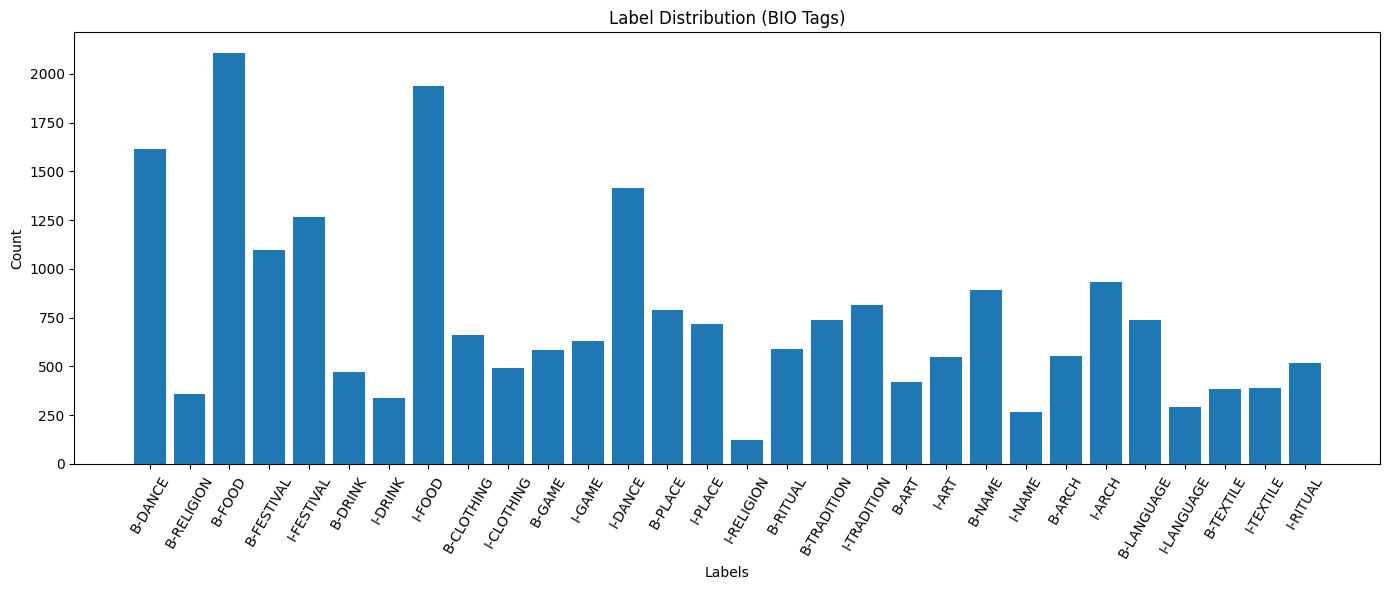

In [18]:
import matplotlib.pyplot as plt

label_counts = {
    "B-DANCE":1617, "B-RELIGION":359, "B-FOOD":2108,
    "B-FESTIVAL":1099, "I-FESTIVAL":1264,
    "B-DRINK":470, "I-DRINK":340,
    "I-FOOD":1940,
    "B-CLOTHING":662, "I-CLOTHING":491,
    "B-GAME":586, "I-GAME":633,
    "I-DANCE":1415,
    "B-PLACE":792, "I-PLACE":719,
    "I-RELIGION":125,
    "B-RITUAL":591,
    "B-TRADITION":736, "I-TRADITION":814,
    "B-ART":418, "I-ART":546,
    "B-NAME":890, "I-NAME":265,
    "B-ARCH":552, "I-ARCH":934,
    "B-LANGUAGE":736, "I-LANGUAGE":291,
    "B-TEXTILE":384, "I-TEXTILE":392,
    "I-RITUAL":518
}

labels = list(label_counts.keys())
values = list(label_counts.values())

# Plot
plt.figure(figsize=(14,6))
plt.bar(labels, values)

plt.xticks(rotation=60)
plt.title("Label Distribution (BIO Tags)")
plt.xlabel("Labels")
plt.ylabel("Count")

plt.tight_layout()

# Save image
plt.savefig("label_distribution.png")

plt.show()

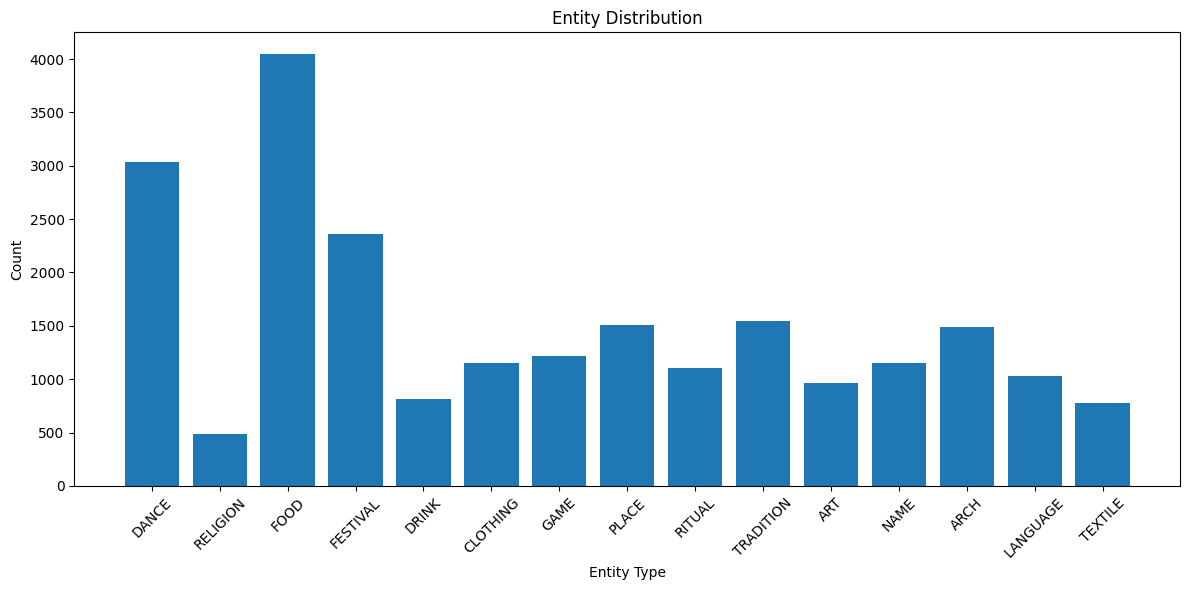

In [19]:
from collections import defaultdict
import matplotlib.pyplot as plt

grouped = defaultdict(int)

for label, count in label_counts.items():
    entity = label.split("-")[1]
    grouped[entity] += count

labels = list(grouped.keys())
values = list(grouped.values())

plt.figure(figsize=(12,6))
plt.bar(labels, values)

plt.xticks(rotation=45)
plt.title("Entity Distribution")
plt.xlabel("Entity Type")
plt.ylabel("Count")

plt.tight_layout()
plt.savefig("entity_distribution.png")

plt.show()

In [20]:
!pip install transformers datasets seqeval -q

In [21]:
import json

with open("csi_ner_dataset_final.json") as f:
    data = json.load(f)

print("Total samples:", len(data))

Total samples: 12000


In [22]:
from sklearn.model_selection import train_test_split

train_data, temp_data = train_test_split(data, test_size=0.2, random_state=42)
val_data, test_data = train_test_split(temp_data, test_size=0.5, random_state=42)

print(len(train_data), len(val_data), len(test_data))

9600 1200 1200


In [23]:
labels = set()

for item in data:
    for tag in item["tags"]:
        labels.add(tag)

labels = sorted(list(labels))

label2id = {label: i for i, label in enumerate(labels)}
id2label = {i: label for label, i in label2id.items()}

print(label2id)

{'B-ARCH': 0, 'B-ART': 1, 'B-CLOTHING': 2, 'B-DANCE': 3, 'B-DRINK': 4, 'B-FESTIVAL': 5, 'B-FOOD': 6, 'B-GAME': 7, 'B-LANGUAGE': 8, 'B-NAME': 9, 'B-PLACE': 10, 'B-RELIGION': 11, 'B-RITUAL': 12, 'B-TEXTILE': 13, 'B-TRADITION': 14, 'I-ARCH': 15, 'I-ART': 16, 'I-CLOTHING': 17, 'I-DANCE': 18, 'I-DRINK': 19, 'I-FESTIVAL': 20, 'I-FOOD': 21, 'I-GAME': 22, 'I-LANGUAGE': 23, 'I-NAME': 24, 'I-PLACE': 25, 'I-RELIGION': 26, 'I-RITUAL': 27, 'I-TEXTILE': 28, 'I-TRADITION': 29, 'O': 30}


In [24]:
from datasets import Dataset

def convert(data):
    return Dataset.from_dict({
        "tokens": [item["tokens"] for item in data],
        "ner_tags": [[label2id[tag] for tag in item["tags"]] for item in data]
    })

train_dataset = convert(train_data)
val_dataset = convert(val_data)
test_dataset = convert(test_data)

In [25]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

def tokenize_and_align_labels(examples):
    tokenized = tokenizer(examples["tokens"], truncation=True, is_split_into_words=True)

    labels = []
    for i, label in enumerate(examples["ner_tags"]):
        word_ids = tokenized.word_ids(batch_index=i)
        label_ids = []

        prev_word = None
        for word_id in word_ids:
            if word_id is None:
                label_ids.append(-100)
            elif word_id != prev_word:
                label_ids.append(label[word_id])
            else:
                label_ids.append(label[word_id])
            prev_word = word_id

        labels.append(label_ids)

    tokenized["labels"] = labels
    return tokenized

train_dataset = train_dataset.map(tokenize_and_align_labels, batched=True)
val_dataset = val_dataset.map(tokenize_and_align_labels, batched=True)
test_dataset = test_dataset.map(tokenize_and_align_labels, batched=True)

Map:   0%|          | 0/9600 [00:00<?, ? examples/s]

Map:   0%|          | 0/1200 [00:00<?, ? examples/s]

Map:   0%|          | 0/1200 [00:00<?, ? examples/s]

In [26]:
from transformers import AutoModelForTokenClassification

model = AutoModelForTokenClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=len(labels),
    id2label=id2label,
    label2id=label2id
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized be

In [27]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    num_train_epochs=5,
    warmup_steps=500,
    weight_decay=0.01,
)

In [28]:
import numpy as np
from seqeval.metrics import f1_score

def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)

    true_predictions = []
    true_labels = []

    for pred, lab in zip(predictions, labels):
        curr_preds = []
        curr_labels = []

        for p_val, l_val in zip(pred, lab):
            if l_val != -100:
                curr_preds.append(id2label[p_val])
                curr_labels.append(id2label[l_val])

        true_predictions.append(curr_preds)
        true_labels.append(curr_labels)

    return {
        "f1": f1_score(true_labels, true_predictions)
    }

In [29]:
from transformers import DataCollatorForTokenClassification

data_collator = DataCollatorForTokenClassification(tokenizer)

In [30]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator,
)

In [31]:
trainer.train()

Step,Training Loss
500,1.278933
1000,0.322163
1500,0.230244
2000,0.149679
2500,0.118177
3000,0.091984


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=3000, training_loss=0.365196652730306, metrics={'train_runtime': 373.8485, 'train_samples_per_second': 128.394, 'train_steps_per_second': 8.025, 'total_flos': 361321144097472.0, 'train_loss': 0.365196652730306, 'epoch': 5.0})

In [32]:
results = trainer.evaluate(test_dataset)
print(results)

{'eval_loss': 0.19127005338668823, 'eval_f1': 0.8649289099526067, 'eval_runtime': 2.7494, 'eval_samples_per_second': 436.462, 'eval_steps_per_second': 54.558, 'epoch': 5.0}


In [33]:

trainer.save_model("final_model_best")
tokenizer.save_pretrained("final_model_best")

print("Model saved successfully!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved successfully!
